 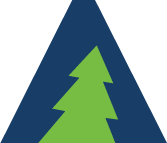 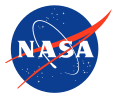 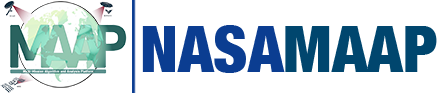   
| 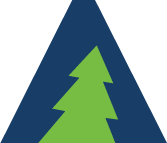 | These products were developed with funding from the [NASA Arctic Boreal Vulnerability Experiment (ABoVE)](https://above.nasa.gov/). |
| ----------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| 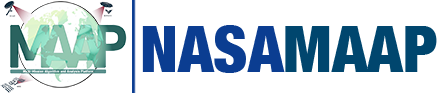 | Code development and data processing are performed on the [NASA Multi-Mission Algorithm and Analysis Platform](https://maap-project.org) |  

# Circumpolar boreal forest structure maps from the `NASA ABoVE Boreal Biomass Mapping` project
### Review details: 
+ v3.1 circumpolar AGB trends 
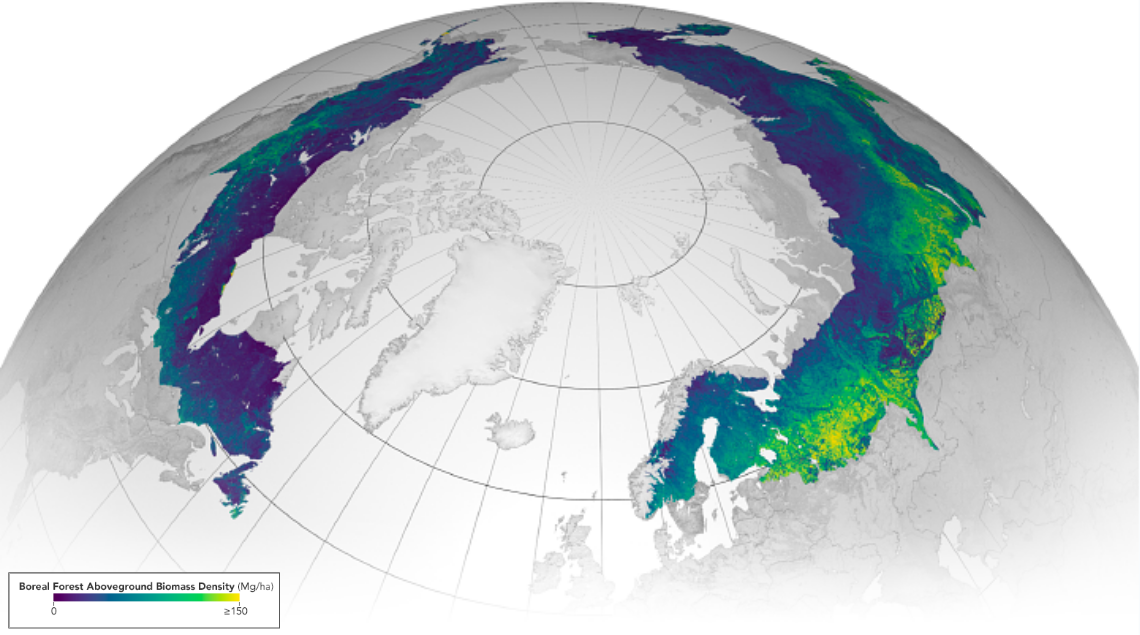

| Contributors | Role | Affiliation | 
| ---------------- | ---------------- | ---------------- |
| Paul Montesano paul.m.montesano@nasa.gov |  Co-I | NASA Goddard Space Flight Center |
| Laura Duncanson lduncans@umd.edu | PI |  Dept. Geographical Sciences, U. Maryland-College Park |
| Nathan Thomas  |  Co-I | Edge Hill University |
| Amy Neuenschwander | Co-I | U. Texas at Austin |
| Eric Guenther |   | U. Texas at Austin |  
| Alex Mandel    |    | DevelopmentSeed, Inc. |  
| Ali Zarringhalam |   | Dept. Geographical Sciences, U. Maryland-College Park | 
| Qiang Zhou |   | NASA Goddard Space Flight Center | 
| David Minor |   | Dept. Geographical Sciences, U. Maryland-College Park |

#### Documentation for circumpolar _biomass density_ (AGB) and _vegetation height_ (HT) maps
+ map resolution: 30 m
+ map year: 2016-2025
+ extent displayed: circumpolar boreal + misc regions further south
+ produced as a set of 90 km square cloud-optimized geotiff (COG) map tiles
+ results derived from a combination of:
  + empirical models linking plant-functional-type allometry relating woody biomass density with vegetation height at spaceborne lidar observations
  + boreal-wide and tile-level empirical models linking spaceborne lidar with other spaceborne covariates.
+ built with `ground reference AGB`, `ICESat-2/ATL08 30m segments`, `Harmonized Landsat/Sentinel-2`, `Copernicus GLO30 DEM`, `ESA Worldcover 2020 v1.0`
+ work performed as part of the `NASA Arctic/Boreal Vulnerability Experiment (ABoVE)` project
+ GitHub repository: https://github.com/lauraduncanson/icesat2_boreal.git

In [2]:
# import os
# os.environ["PROJ_DATA"] = "/opt/conda/envs/titiler/share/proj"
# os.environ["PROJ_LIB"] = "/opt/conda/envs/titiler/share/proj"
# !pip install cogeo_mosaic

In [1]:
!pip install cogeo_mosaic==8.2.0

  Using cached cogeo_mosaic-8.2.0-py3-none-any.whl.metadata (19 kB)
  Using cached supermorecado-0.2.0-py3-none-any.whl.metadata (9.2 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached cogeo_mosaic-8.2.0-py3-none-any.whl (40 kB)
Using cached supermorecado-0.2.0-py3-none-any.whl (15 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)


In [2]:
# from maap.maap import MAAP
# maap = MAAP()
import geopandas
import pandas as pd
import os
import sys
import importlib

ICESAT2_BOREAL_LIB_PATH = '/projects/code/icesat2_boreal/lib'   
sys.path.append(ICESAT2_BOREAL_LIB_PATH)
import maplib_folium
import mosaiclib
from mosaiclib import *

# Map
Note: zoom-in to display map tiles

In [3]:
boreal_tiles = geopandas.read_file(boreal_tile_index_path)

<Axes: >

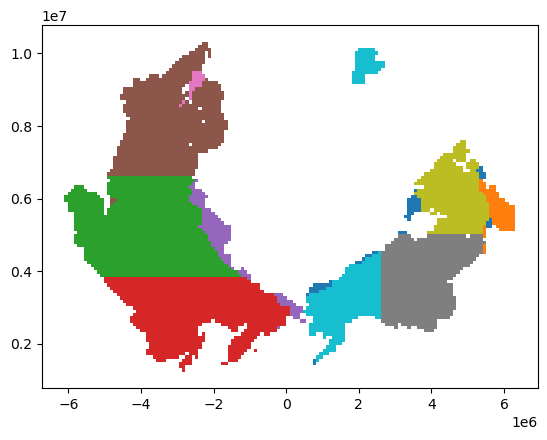

In [4]:
boreal_tiles.plot(column='tile_group')

In [5]:
import importlib
importlib.reload(mosaiclib)
importlib.reload(maplib_folium)

<module 'maplib_folium' from '/projects/code/icesat2_boreal/lib/maplib_folium.py'>

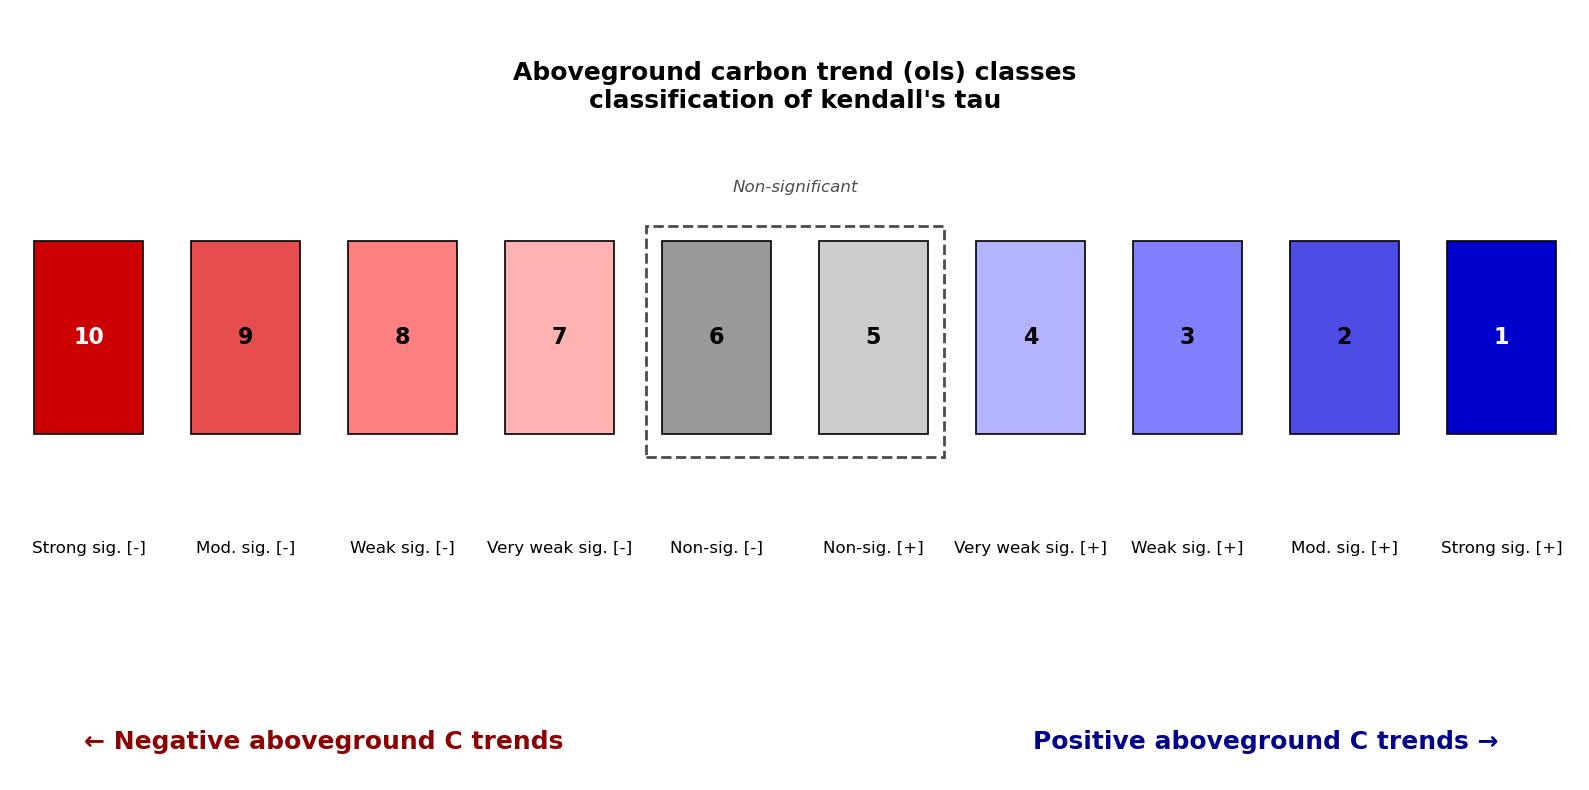

In [6]:
# Create and display the legend
maplib_folium.create_kendall_horizontal_legend()

In [75]:
AGB_TILES_LAYER_LIST = []
HLS_TILES_LAYER_LIST = []
SHOW_CBAR=True
# for YEAR in list(range(2019,2019+1)):
for YEAR in [2019,2024]:
    
    AGB_TILES_LAYER_LIST.append(maplib_folium.make_tiles_layer_dict(
                                                       None,  
                                                       mosaiclib.AGB_MOSAIC_JSON_FN_DICT[f'{YEAR}_v3.1_multiyr'], 
                                                       f"AGBD mean {YEAR} [Mg/ha] v3.1 multiyr model", 
                                                       SHOW_CBAR=SHOW_CBAR, 
                                                       PARAMS_DICT = {"rescale": f"0, 125", "bidx":"1", "colormap_name": "viridis"})
                           )
    # HLS_TILES_LAYER_LIST.append(maplib_folium.make_tiles_layer_dict(
    #                                                 None,
    #                                                 mosaiclib.HLS_MOSAIC_JSON_FN_DICT[f'{YEAR}'],
    #                                                 f'HLS {YEAR} NBR2', 
    #                                                 SHOW_CBAR=SHOW_CBAR,
    #                                                 PARAMS_DICT = {"rescale": f"0.25, 0.45", "bidx":"13", "colormap_name": "nipy_spectral"})
    #                        )
    if SHOW_CBAR: SHOW_CBAR=False

Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/BOREAL_MAP/v3.1.0/AGB_H30_2019/full_run_niter30_multiyear_atl08v6/AGB_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': '296e7703-5313-4de5-8015-55727e8018e0', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/296e7703-5313-4de5-8015-55727e8018e0/tiles/{z}/{x}/{y}@1x?rescale=0%2C+125&bidx=1&colormap_name=viridis'], 'minzoom': 6, 'maxzoom': 18, 'bounds': [-179.99999, 35.80632446895021, 179.99999, 78.53132756237311], 'center': [0.0, 57.16882601566166, 6]}
Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/BOREAL_MAP/v3.1.0/AGB_H30_2024/full_run_niter30_multiyear_atl08v6/AGB_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': '03f33d6e-d197-4a05-92c8-500cdd75da99', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/03f33d6e-d197-4a05-92c8-500cdd75da99/tiles/{z}/{x}

In [99]:
AGBUNET_TILES_LAYER_LIST = []

SHOW_CBAR=False
for YEAR in [2019,2024]:
    
    AGBUNET_TILES_LAYER_LIST.append(maplib_folium.make_tiles_layer_dict(
                                                       None,  
                                                       f's3://maap-ops-workspace/shared/montesano/DPS_tile_lists/AGB_UNET/v1.1/AGB_AK/AGB_UNET_tindex_master_{YEAR}_mosaic.json', 
                                                       f"AGBD mean {YEAR} [Mg/ha] UNET model", 
                                                       SHOW_CBAR=SHOW_CBAR, 
                                                       PARAMS_DICT = {"rescale": f"0, 125", "bidx":"1", "colormap_name": "viridis"})
                           )

Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/AGB_UNET/v1.1/AGB_AK/AGB_UNET_tindex_master_2019_mosaic.json
{'tilejson': '2.2.0', 'name': '02a7c88d-798f-437f-b834-6901de5d20e1', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/02a7c88d-798f-437f-b834-6901de5d20e1/tiles/{z}/{x}/{y}@1x?rescale=0%2C+125&bidx=1&colormap_name=viridis'], 'minzoom': 6, 'maxzoom': 18, 'bounds': [-172.5933192756914, 48.68927943362282, -73.09438281178458, 71.81286727353253], 'center': [-122.843851043738, 60.25107335357768, 6]}
Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/AGB_UNET/v1.1/AGB_AK/AGB_UNET_tindex_master_2024_mosaic.json
{'tilejson': '2.2.0', 'name': '16ca1d8f-5058-4ba6-a11d-61a889a63353', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/16ca1d8f-5058-4ba6-a11d-61a889a63353/tiles/{z}/{x}/{y}@1x?rescale=0%2C+125&bidx=1&colorma

In [112]:
DIFFYEARS = '2024_2019'
DIFFYEARS.replace('_','-')

'2024-2019'

In [125]:
AGBUNETDIFF_TILES_LAYER_LIST = []

SHOW_CBAR=True
for DIFFYEARS in ['2024_2019']:
    
    AGBUNETDIFF_TILES_LAYER_LIST.append(maplib_folium.make_tiles_layer_dict(
                                                       None,  
                                                       f's3://maap-ops-workspace/shared/montesano/DPS_tile_lists/AGB_DIFF/AGB_DIFF_tindex_master_{DIFFYEARS}_mosaic.json', 
                                                       f"AGBD Difference mean {DIFFYEARS.replace('_','-')} [Mg/ha] UNET model", 
                                                       SHOW_CBAR=SHOW_CBAR, 
                                                       PARAMS_DICT = {"rescale": f"-15, 15", "bidx":"1", "colormap_name": "RdYlGn"})
                           )

Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/AGB_DIFF/AGB_DIFF_tindex_master_2024_2019_mosaic.json
{'tilejson': '2.2.0', 'name': 'a699d0c8-2d23-4a27-8426-d52daef54d68', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/a699d0c8-2d23-4a27-8426-d52daef54d68/tiles/{z}/{x}/{y}@1x?rescale=-15%2C+15&bidx=1&colormap_name=rdylgn'], 'minzoom': 6, 'maxzoom': 18, 'bounds': [-172.5933192756914, 52.82048644723165, -128.1609330350963, 71.81286727353253], 'center': [-150.37712615539385, 62.31667686038209, 6]}


In [34]:
CACC_AGE_LIST = [
    maplib_folium.make_tiles_layer_dict(
        None, 
        mosaiclib.MISC_MOSAIC_JSON_FN_DICT['CACC_2020_v3.1_multiyr_nsims050'], 
        "Forest Age 2020 [updated ensemble mean, 30m] 2020 (updated with TerraPulse and GAMI v2.0)", 
        SHOW_CBAR=True, 
        PARAMS_DICT = {"rescale": f"1,250", "bidx":"9", "colormap_name": 'gist_earth'}
        ),
    maplib_folium.make_tiles_layer_dict(
        None, 
        mosaiclib.MISC_MOSAIC_JSON_FN_DICT['CACC_2020_v3.1_multiyr_nsims050'], 
        "Carbon accumulation (v3.1) 2020 [MgC/ha/yr]", 
        SHOW_CBAR=True, 
        PARAMS_DICT = {"rescale": f"0,1", "bidx":"1", "colormap_name": 'turbo'}
        ),
    maplib_folium.make_tiles_layer_dict(
        None, 
        mosaiclib.MISC_MOSAIC_JSON_FN_DICT['CACC_2020_v3.1_multiyr_nsims050'], 
        "Carbon accumulation Uncertainty (v3.1) 2020 [MgC/ha/yr]", 
        SHOW_CBAR=True, 
        PARAMS_DICT = {"rescale": f"0,0.25", "bidx":"2", "colormap_name": 'magma'}
        ),
# maplib_folium.make_tiles_layer_dict(
#     None, 
#     mosaiclib.MISC_MOSAIC_JSON_FN_DICT['TTE_2010'], 
#     "TTE forest structure pattern", 
#     SHOW_CBAR=True, 
#     PARAMS_DICT = {"rescale": f"0,11", "bidx":"4", "colormap_name": 'tab20c'}
# ),
]

Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/CACC/carbon_accumulation_v3/CACC_2020_v3.1_multiyr_nsims050/CACC_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': 'f7373791-9cfe-41c9-b902-7d9c400c1ac7', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/f7373791-9cfe-41c9-b902-7d9c400c1ac7/tiles/{z}/{x}/{y}@1x?rescale=1%2C250&bidx=9&colormap_name=gist_earth'], 'minzoom': 6, 'maxzoom': 18, 'bounds': [-179.99999, 35.80632446895021, 179.99999, 78.53132756237311], 'center': [0.0, 57.16882601566166, 6]}
Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/CACC/carbon_accumulation_v3/CACC_2020_v3.1_multiyr_nsims050/CACC_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': '3c75bc0a-a986-4b0b-a47f-0f3d057d099a', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/3c75bc0a-a986-4b0b-a47f-0f3d057d099a/tiles/{z}/{x}/{y}@1x?

In [14]:
TRENDS_LIST_2020_2025 = [
    maplib_folium.make_tiles_layer_dict(
        None, 
        mosaiclib.MISC_MOSAIC_JSON_FN_DICT['TRENDOLS_AGB_v3.1_multiyr_2020-2025'], 
        "AGB trends (OLS) 2020-2025 [Mg/ha/yr]", 
        SHOW_CBAR=False, 
        #PARAMS_DICT = {"rescale": f"-2,2", "bidx":"1", "colormap_name": 'BrBG'}
        PARAMS_DICT = {"rescale": f"-2,2", "bidx":"1", "colormap_name": 'PiYG'}
        ),
    
    maplib_folium.make_tiles_layer_dict(
        None, 
        mosaiclib.MISC_MOSAIC_JSON_FN_DICT['TRENDCLASS_AGB_v3.1_multiyr_2020-2025'], 
        "AGB trend classes 2020-2025 [Mg/ha/yr]", 
        SHOW_CBAR=False, 
        PARAMS_DICT = {"rescale": f"0,10", "bidx":"1", "colormap_name": 'RdBu_r'}
        ),
] 

Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/TRENDOLS/compute_trends_ols_v3/AGB_v3.1_multiyr_2020-2025/TRENDOLS_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': '57bf947d-e326-4e34-bb53-603951054ab6', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/57bf947d-e326-4e34-bb53-603951054ab6/tiles/{z}/{x}/{y}@1x?rescale=-2%2C2&bidx=1&colormap_name=piyg'], 'minzoom': 6, 'maxzoom': 18, 'bounds': [-179.99999, 43.70498917081278, 179.99999, 75.94119008920045], 'center': [0.0, 59.82308963000661, 6]}
Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/TRENDCLASS/compute_trends_ols_v3/AGB_v3.1_multiyr_2020-2025/TRENDCLASS_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': '48b118f4-351c-4484-8d70-a6f45215eea7', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/48b118f4-351c-4484-8d70-a6f45215eea7/tiles/{z}/{x}/{y}@1x

In [15]:
TRENDS_NDVI_HLS = [
    maplib_folium.make_tiles_layer_dict(
        None, 
        mosaiclib.MISC_MOSAIC_JSON_FN_DICT['NDVI_trends_HLS'], 
        "NDVI Trends across HLS", 
        SHOW_CBAR=True, 
        PARAMS_DICT = {"rescale": f"-0.02,0.02", "bidx":"1", "colormap_name": 'BrBG'}
        ),
    
] 

Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/TRENDNDVI_SLOPE/main/TRENDNDVI_SLOPE_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': '3b8b78f8-5ab7-4062-ba02-31fee8ecacb4', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/3b8b78f8-5ab7-4062-ba02-31fee8ecacb4/tiles/{z}/{x}/{y}@1x?rescale=-0.02%2C0.02&bidx=1&colormap_name=brbg'], 'minzoom': 6, 'maxzoom': 18, 'bounds': [-180.0, 51.0, -129.0, 72.0], 'center': [-154.5, 61.5, 6]}


In [16]:
TCC_LIST = [
        # maplib_folium.make_tiles_layer_dict(
        #                                     None, 
        #                                     mosaiclib.MISC_MOSAIC_JSON_FN_DICT['TCC_TP_1984'], 
        #                                     "Tree canopy cover 1984", 
        #                                     SHOW_CBAR=True, 
        #                                     PARAMS_DICT = {"rescale": f"0,75", "bidx":"1", "colormap_name": 'YlGn'}
        #                                     ),
        #     maplib_folium.make_tiles_layer_dict(
        #                                     None, 
        #                                     mosaiclib.MISC_MOSAIC_JSON_FN_DICT['TCC_TP_2020'], 
        #                                     "Tree canopy cover 2020", 
        #                                     SHOW_CBAR=True, 
        #                                     PARAMS_DICT = {"rescale": f"0,75", "bidx":"1", "colormap_name": 'YlGn'}
        #                                     ),
        maplib_folium.make_tiles_layer_dict(
                                            None, 
                                            mosaiclib.MISC_MOSAIC_JSON_FN_DICT['TCCTREND_TP_2020'], 
                                            "Tree canopy cover trend 1984-2020", 
                                            SHOW_CBAR=True, 
                                            PARAMS_DICT = {"rescale": f"-2,2", "bidx":"1", "colormap_name": 'BrBG'}
                                            )
]

Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/TCCTREND/build_stack_v2023_2/TCCTREND_TP_2020/TCCTREND_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': 'ff4e9bef-c520-457c-9eae-db59302fcfa7', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/ff4e9bef-c520-457c-9eae-db59302fcfa7/tiles/{z}/{x}/{y}@1x?rescale=-2%2C2&bidx=1&colormap_name=brbg'], 'minzoom': 6, 'maxzoom': 18, 'bounds': [-167.35203068347897, 45.06123765440018, 179.99999, 73.58880193314995], 'center': [6.323979658260512, 59.32501979377507, 6]}


In [22]:
TRENDS_LIST_2016_2025 = [
    
    maplib_folium.make_tiles_layer_dict(
        None, 
        mosaiclib.MISC_MOSAIC_JSON_FN_DICT['TRENDOLS_AGB_v3.1_multiyr_2016-2025'], 
        "AGB trends (OLS) 2016-2025 [Mg/ha/yr]", 
        SHOW_CBAR=True, 
        #PARAMS_DICT = {"rescale": f"-2,2", "bidx":"1", "colormap_name": 'BrBG'}
        PARAMS_DICT = {"rescale": f"-2,2", "bidx":"1", "colormap_name": 'PiYG'}
        ),
    
    maplib_folium.make_tiles_layer_dict(
        None, 
        mosaiclib.MISC_MOSAIC_JSON_FN_DICT['TRENDCLASS_AGB_v3.1_multiyr_2016-2025'], 
        "AGB trend classes 2016-2025 [Mg/ha/yr]", 
        SHOW_CBAR=True, 
        PARAMS_DICT = {"rescale": f"0,10", "bidx":"1", "colormap_name": 'RdBu_r'}
        )
    
]

Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/TRENDOLS/compute_trends_ols_v3/AGB_v3.1_multiyr_2016-2025/TRENDOLS_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': '38888c71-675d-42ac-8f85-4bd9426ff3e6', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/38888c71-675d-42ac-8f85-4bd9426ff3e6/tiles/{z}/{x}/{y}@1x?rescale=-2%2C2&bidx=1&colormap_name=piyg'], 'minzoom': 6, 'maxzoom': 18, 'bounds': [-168.08033084855822, 43.70498917081278, 153.36286216978488, 72.10435179037718], 'center': [-7.358734339386672, 57.90467048059498, 6]}
Registering mosaic with Titiler: s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/TRENDCLASS/compute_trends_ols_v3/AGB_v3.1_multiyr_2016-2025/TRENDCLASS_tindex_master_mosaic.json
{'tilejson': '2.2.0', 'name': '1297ff1d-5589-479a-afb7-6a278333e386', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['https://titiler-pgstac.maap-project.org/mosaics/1297ff1d-5589-479a-afb7-

In [126]:
m = maplib_folium.MAP_REGISTERED_DPS_RESULTS(
                                boreal_tiles,
                                None,
                                CHECK_TILES_NAME='',
                                map_width=750, map_height=500, SHOW_WIDGETS=False,
                                ADD_TILELAYER =
                                    #TCC_LIST +\
                                    AGBUNETDIFF_TILES_LAYER_LIST +\
                                    AGBUNET_TILES_LAYER_LIST +\
                                    AGB_TILES_LAYER_LIST +\
                                    CACC_AGE_LIST +\
                                    # TRENDS_LIST_2020_2025 +\
                                    TRENDS_LIST_2016_2025 #+\
                                    #TRENDS_NDVI_HLS
                                    #HLS_TILES_LAYER_LIST,
                                    #ADD_4326_GPKG = [DICT_FIRES_NRCAN, DICT_FIRES_FIREDPY]
                             )


Adding layer AGBD Difference mean 2024-2019 [Mg/ha] UNET model...
Adding layer AGBD mean 2019 [Mg/ha] UNET model...
Adding layer AGBD mean 2024 [Mg/ha] UNET model...
Adding layer AGBD mean 2019 [Mg/ha] v3.1 multiyr model...
Adding layer AGBD mean 2024 [Mg/ha] v3.1 multiyr model...
Adding layer Forest Age 2020 [updated ensemble mean, 30m] 2020 (updated with TerraPulse and GAMI v2.0)...
Adding layer Carbon accumulation (v3.1) 2020 [MgC/ha/yr]...
Adding layer Carbon accumulation Uncertainty (v3.1) 2020 [MgC/ha/yr]...
Adding layer AGB trends (OLS) 2016-2025 [Mg/ha/yr]...
Adding layer AGB trend classes 2016-2025 [Mg/ha/yr]...


## Build in raster query

In [127]:
BASE = 'https://titiler-pgstac.maap-project.org/mosaics'
AGBUNET_2019_POINT = f'{BASE}/02a7c88d-798f-437f-b834-6901de5d20e1/point/{{lon}},{{lat}}'
AGBUNET_2024_POINT = f'{BASE}/16ca1d8f-5058-4ba6-a11d-61a889a63353/point/{{lon}},{{lat}}'

AGBUNETDIFF_2024_2019_POINT = f'{BASE}/3c3bc013-7d9a-4cb8-902b-dbda0816bf12/point/{{lon}},{{lat}}'

AGB_2019_POINT = f'{BASE}/296e7703-5313-4de5-8015-55727e8018e0/point/{{lon}},{{lat}}'
AGB_2024_POINT = f'{BASE}/03f33d6e-d197-4a05-92c8-500cdd75da99/point/{{lon}},{{lat}}'

AGB_2025_POINT = f'{BASE}/a9a8784a-f7a3-4db6-be1e-92733fb7f213/point/{{lon}},{{lat}}'
CACC_2020_POINT = f'{BASE}/1a909d38-dfce-4e3d-959f-2717dc772aed/point/{{lon}},{{lat}}'
TREND_20162025_POINT = f'{BASE}/2930623a-621a-4825-b830-91e523e46619/point/{{lon}},{{lat}}'
TRENDS_NDVI_HLS_POINT = f'{BASE}/2fec0901-1754-4a4d-9421-218497e1f7f8/point/{{lon}},{{lat}}'

query_layers = [
    {'section': 'AGB density 2019 UNET', 'name': 'mean',
     'point_url': f'{AGBUNET_2019_POINT}?bidx=1', 'units': 'Mg/ha'},
    {'section': 'AGB density 2019 UNET', 'name': 'st dev',
     'point_url': f'{AGBUNET_2019_POINT}?bidx=2', 'units': 'Mg/ha'},

    {'section': 'AGB density difference 2024-2019 UNET', 'name': 'mean',
     'point_url': f'{AGBUNETDIFF_2024_2019_POINT}?bidx=1', 'units': 'Mg/ha'},
    
    {'section': 'AGB density 2024 UNET', 'name': 'mean',
     'point_url': f'{AGBUNET_2024_POINT}?bidx=1', 'units': 'Mg/ha'},
    {'section': 'AGB density 2024 UNET', 'name': 'st dev',
     'point_url': f'{AGBUNET_2024_POINT}?bidx=2', 'units': 'Mg/ha'},

    {'section': 'AGB density 2019', 'name': 'mean',
     'point_url': f'{AGB_2019_POINT}?bidx=1', 'units': 'Mg/ha'},
    {'section': 'AGB density 2019', 'name': 'st dev',
     'point_url': f'{AGB_2019_POINT}?bidx=2', 'units': 'Mg/ha'},
    {'section': 'AGB density 2024', 'name': 'mean',
     'point_url': f'{AGB_2024_POINT}?bidx=1', 'units': 'Mg/ha'},
    {'section': 'AGB density 2024', 'name': 'st dev',
     'point_url': f'{AGB_2024_POINT}?bidx=2', 'units': 'Mg/ha'},
    
    {'section': 'AGB density 2025', 'name': 'mean',
     'point_url': f'{AGB_2025_POINT}?bidx=1', 'units': 'Mg/ha'},
    {'section': 'AGB density 2025', 'name': 'st dev',
     'point_url': f'{AGB_2025_POINT}?bidx=2', 'units': 'Mg/ha'},

    {'section': 'AGB trend 2016–2025', 'name': 'slope (OLS)',
     'point_url': f'{TREND_20162025_POINT}?bidx=1', 'units': 'Mg/ha/yr'},
    {'section': 'AGB trend 2016–2025', 'name': 'p-value (Mann–Kendall)',
     'point_url': f'{TREND_20162025_POINT}?bidx=7', 'units': ''},

    {'section': 'Carbon Accumulation 2020', 'name': 'mean',
     'point_url': f'{CACC_2020_POINT}?bidx=1', 'units': 'MgC/ha/yr'},
    {'section': 'Carbon Accumulation 2020', 'name': 'st dev',
     'point_url': f'{CACC_2020_POINT}?bidx=2', 'units': 'MgC/ha/yr'},
    
    {'section': 'Forest Age 2020', 'name': 'mean',
     'point_url': f'{CACC_2020_POINT}?bidx=9', 'units': 'yr'},
    {'section': 'Forest Age 2020', 'name': 'st dev',
     'point_url': f'{CACC_2020_POINT}?bidx=10', 'units': 'yr'},
    
    {'section': 'HLS NDVI Anomalies from 2025', 'name': 'what to call this?',
     'point_url': f'{TRENDS_NDVI_HLS}?bidx=1', 'units': 'none'},
    
]

# After m is built with your tile layers:
m = maplib_folium.add_pixel_query(m, query_layers, decimals=4)

In [128]:
from folium import GeoJson, features

In [129]:
from folium import LayerControl

In [130]:
import folium
from folium.features import GeoJson, GeoJsonTooltip
import geopandas as gpd

val_plots = gpd.read_file(
    '/projects/my-private-bucket/reference/eurasia_forest_structure_plots_agbd_20260513.gpkg'
)

In [131]:
val_plots['years_since_field_obs'] = 2020 - val_plots['year']

# Disturbance after field obs → mapped age < time since obs → RS NOT representative
val_plots['post_obs_disturbance'] = (
    val_plots['value_CACC_2020_v3.1_multiyr_age_mean']
    < val_plots['years_since_field_obs']
)

COLOR_OK    = '#1a9850'   # no disturbance after obs → RS representative
COLOR_BAD   = '#d73027'   # post-obs disturbance → RS not representative
COLOR_NA    = '#999999'

def style_plot(feature):
    p = feature['properties']
    age_map = p.get('value_CACC_2020_v3.1_multiyr_age_mean')
    if age_map is None:
        fill = COLOR_NA
    else:
        fill = COLOR_BAD if p.get('post_obs_disturbance') else COLOR_OK
    return {
        'color': 'black', 'weight': 1,
        'fillColor': fill, 'fillOpacity': 0.85,
    }

val_plots_layer = GeoJson(
    data=val_plots,
    name='Validation plots (Eurasia)',
    marker=folium.CircleMarker(radius=5, fill=True, fill_opacity=0.85, weight=1),
    style_function=style_plot,
    tooltip=GeoJsonTooltip(
        fields=['year', 'site', 'group_name', 'agbd_v2_mg_ha',
                'years_since_field_obs',
                'value_CACC_2020_v3.1_multiyr_age_mean',
                'post_obs_disturbance'],
        aliases=['Field obs year', 'Site', 'Group', 'AGB density [Mg/ha]',
                 'Years (in 2020) since field obs',
                 'Mapped age in 2020 [yr]',
                 'Post-obs disturbance?'],
        localize=True, sticky=True,
    ),
    popup=folium.GeoJsonPopup(
        fields=['year', 'site', 'group_name', 'agbd_v2_mg_ha',
                'years_since_field_obs',
                'value_CACC_2020_v3.1_multiyr_age_mean',
                'post_obs_disturbance'],
        aliases=['Field obs year', 'Site', 'Group', 'AGB density [Mg/ha]',
                 'Years (in 2020) since field obs',
                 'Mapped age in 2020 [yr]',
                 'Post-obs disturbance?'],
    ),
)

# Remove existing LayerControl
to_remove = [k for k, child in m._children.items()
             if isinstance(child, folium.LayerControl)]
for k in to_remove:
    del m._children[k]

val_plots_layer.add_to(m)
folium.LayerControl(collapsed=True).add_to(m)

In [ ]:
import branca
from folium.elements import MacroElement
from jinja2 import Template

class FloatingLegend(MacroElement):
    def __init__(self, html):
        super().__init__()
        self._name = 'FloatingLegend'
        self._html = html
        self._template = Template("""
        {% macro script(this, kwargs) %}
        (function() {
            var wrapper = document.createElement('div');
            wrapper.innerHTML = {{ this._html|tojson }};
            var legend = wrapper.firstElementChild;
            {{ this._parent.get_name() }}.getContainer().appendChild(legend);
        })();
        {% endmacro %}
        """)

legend_html = """
<div style="position: absolute; bottom: 60px; right: 12px; z-index: 9999;
            background: rgba(255,255,255,0.92); padding: 8px 10px;
            border: 1px solid #888; border-radius: 4px;
            font-family: sans-serif; font-size: 11px; max-width: 240px;">
  <div style="font-weight: bold; margin-bottom: 4px;">Field plot vs. mapped age</div>
  <div style="display:flex; align-items:center; margin: 2px 0;">
    <span style="width:12px; height:12px; background:#1a9850;
                 border:1px solid #555; margin-right:6px; border-radius:50%;"></span>
    RS suggests no disturbance since field obs
  </div>
  <div style="display:flex; align-items:center; margin: 2px 0;">
    <span style="width:12px; height:12px; background:#d73027;
                 border:1px solid #555; margin-right:6px; border-radius:50%;"></span>
    RS not representative: [1] Post-obs disturbance [2] non-forest designation
  </div>
  <div style="display:flex; align-items:center; margin: 2px 0;">
    <span style="width:12px; height:12px; background:#999999;
                 border:1px solid #555; margin-right:6px; border-radius:50%;"></span>
    No mapped age
  </div>
</div>
"""

m.add_child(FloatingLegend(legend_html))

In [133]:
out_html = '/projects/code/maap_tools/maps/Review_maps_v3.1.html'
#out_html = '/projects/code/maap_tools/maps/Review_maps_HLS_trends.html'

### Save to html

In [134]:
import os
from datetime import datetime


# 1. Save the map as usual
m.save(out_html)

# 2. Build the header HTML (title + image + description)
header_html = f"""
<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
            max-width: 1600px; margin: 0 auto; padding: 24px 32px;">
  <h1 style="margin-bottom: 8px;">
    Circumpolar boreal forest structure maps
  </h1>
  <h3 style="margin-top: 0; color: #555; font-weight: normal;">
    NASA ABoVE Boreal Biomass Mapping Project
  </h3>

  <div style="display:flex; gap:24px; align-items:flex-start; margin: 16px 0 24px 0;">
    <img src="thumbnail_above.png" width="240"
         style="border:1px solid #ccc; border-radius:4px; flex-shrink:0;">
    <div style="font-size: 14px; line-height: 1.5; color: #333;">
      <p>
        Interactive maps:
      </p>
      <ul>
        <li><b>Aboveground biomass (AGB) density trends, 2016–2025 & 2020-2025</b> — annual rate of change
            (Mg/ha/yr) derived from a multi-year OLS fit, displayed with the PiYG diverging palette. *Note yet complete for circumpolar domain.*</li>
        <li><b>Aboveground biomass (AGB) density annually, 2016–2025</b> — annual rate of change
            (Mg/ha) derived from a multi-year ICESat-2 ~ HLS modelling, displayed with the viridis palette. Reference: Duncanson et al. 2026 https://doi.org/10.1016/j.rse.2026.115406</li>
        <li><b>Boreal forest tree cover trends (%/year), 1984-2020</b> —annual rate of change in boreal-calibrated tree canopy cover (%/year) from Landsat record. Reference: Feng et al. 2026 https://doi.org/10.5194/bg-23-1089-2026 </li>
        <li><b>Forest age, 2020</b> — combined estimate of stand age (years) based on multiple sources. </li>
        <li><b>Carbon accumulation, 2020</b> — an estimate of woody carbon accumulation (MgC/ha/yr). </li>
      </ul>
      <p>
        Use the layer-control panel (top right) to toggle between products, and the legend
        (bottom left) for class definitions. Click the fullscreen button for an expanded view.
      </p>
    </div>
  </div>
    <table style="border-collapse: collapse; margin: 16px 0 24px 0; font-size: 13px;">
    <thead>
      <tr style="background:#f2f2f2;">
        <th style="border:1px solid #ccc; padding:6px 12px; text-align:left;">Author</th>
        <th style="border:1px solid #ccc; padding:6px 12px; text-align:left;">Affiliation</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="border:1px solid #ccc; padding:6px 12px;">Paul Montesano, PhD</td>
        <td style="border:1px solid #ccc; padding:6px 12px;">NASA Goddard Space Flight Center / Earth System Science Interdisciplinary Center, U. Maryland-College Park</td>
      </tr>
    </tbody>
  </table>
  <div style="display: flex; justify-content: space-between; align-items: center;
              margin-top: 18px; padding-top: 12px; border-top: 1px solid #e0e6ee;
              font-size: 0.85em; color: #718096;">
    <span style="font-style: italic;">Work in progress</span>
    <span><b>Contact:</b> <a href="mailto:paul.m.montesano@nasa.gov">paul.m.montesano@nasa.gov</a></span>
    <span><b>Last updated:</b> {datetime.now().strftime('%Y-%m-%d %H:%M UTC')}</span>
  </div>
</div>
"""

# 3. CSS to make the folium map fill the page width and a tall portion of the viewport
fullwidth_css = """
<style>
  body { margin: 0; padding: 0; }
  /* Folium map container — override fixed width/height */
  .folium-map {
    width: 100% !important;
    height: 45vh !important;
    max-width: 100% !important;
  }
  /* If folium wraps the map in a Figure div, also stretch it */
  div[id^="map_"] {
    width: 100% !important;
    height: 45vh !important;
  }
</style>
"""

# 4. Inject header + CSS right after <body>
with open(out_html, 'r') as f:
    html = f.read()

html = html.replace('<body>', f'<body>\n{fullwidth_css}\n{header_html}', 1)

with open(out_html, 'w') as f:
    f.write(html)

print(f"Saved {out_html} — push to GitHub to view at:")
print(f"  https://pahbs.github.io/maap_tools/maps/{out_html}")


Saved /projects/code/maap_tools/maps/Review_maps_v3.1.html — push to GitHub to view at:
  https://pahbs.github.io/maap_tools/maps//projects/code/maap_tools/maps/Review_maps_v3.1.html


In [ ]:
m